In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('/kaggle/input/datasets/brendan45774/test-file/tested.csv')

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [5]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [6]:
data['Age'].isnull().sum()

np.int64(86)

In [7]:
data['Age'] = data['Age'].fillna(data['Age'].mean())

In [8]:
data.drop('Cabin', axis =1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.50000,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00000,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.00000,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.00000,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00000,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,30.27259,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.00000,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.50000,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,30.27259,0,0,359309,8.0500,S


In [9]:
data['Sex'] = data['Sex'].map({'male' : 0, 'female' : 1})

In [10]:
x = data[['Pclass', 'Age', 'Sex']]
y = data['Survived']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2)

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [15]:
predictions = model.predict(x_test)

In [16]:
from sklearn.metrics import accuracy_score

In [17]:
accuracy = accuracy_score(y_test,predictions)

In [18]:
print(accuracy)

1.0


In [19]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [20]:
data[['SibSp','Parch']].isnull().sum()

SibSp    0
Parch    0
dtype: int64

In [21]:
z = data[['Age','Parch','Sex','SibSp','Pclass']]
y = data['Survived']

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
z_train,z_test,y_train,y_test = train_test_split(z,y,test_size = 0.2,random_state = 42)

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
model = LogisticRegression()
model.fit(z_train,y_train)

LogisticRegression()

In [26]:
predictions = model.predict(z_test)

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,predictions)

In [27]:
print(acc)

1.0


In [28]:
m = data[['Age', 'Pclass','SibSp','Parch']]
y = data['Survived']

In [29]:
from sklearn.model_selection import train_test_split
m_train,m_test,y_train,y_test = train_test_split(m,y,test_size = 0.2, random_state = 42)

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
model = LogisticRegression()
model.fit(m_train,y_train)

LogisticRegression()

In [32]:
predictions = model.predict(m_test)

In [33]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,predictions)
print(acc)

0.6190476190476191


In [34]:
model.coef_

array([[-0.00047795, -0.35836218,  0.14120192,  0.19596358]])

In [35]:
X = data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch']]
y = data['Survived']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)



LogisticRegression()

In [36]:
predictions = model.predict(X_test)

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, predictions)
print(acc)

model.coef_

1.0


array([[-1.66869076e-01,  6.32679149e+00,  2.05238419e-04,
         7.22245634e-02,  9.46497688e-02]])

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

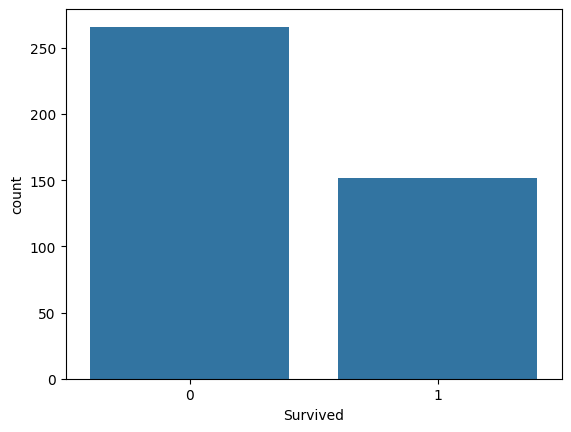

In [38]:
sns.countplot(x='Survived', data=data)
plt.show()

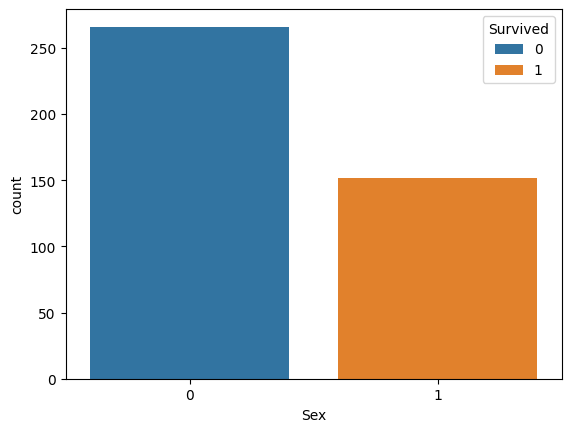

In [39]:
sns.countplot(x='Sex', hue='Survived', data=data)
plt.show()